In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%cd /content/drive/MyDrive/train_yolov8

/content/drive/MyDrive/train_yolov8


In [4]:
import os
HOME = os.getcwd()
print(HOME)

/content/drive/MyDrive/train_yolov8


In [5]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [6]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.4 MB/s eta 0:00:00


In [7]:
from ultralytics import YOLO

from IPython.display import display, Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# importing dataset from Roboflow

In [8]:
!mkdir {HOME}/datasets

!pip install roboflow --quiet

import roboflow

roboflow.login()



mkdir: cannot create directory ‘/content/drive/MyDrive/train_yolov8/datasets’: File exists
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 26.3 MB/s eta 0:00:00
visit https://app.roboflow.com/auth-cli to get your authentication token.
Paste the authentication token here: ··········


In [9]:
%cd {HOME}/datasets
rf = roboflow.Roboflow()
project = rf.workspace("pothole-detection-cluve").project("pothole-detection-yabek")
dataset = project.version(4).download("yolov8")

/content/drive/MyDrive/train_yolov8/datasets
loading Roboflow workspace...
loading Roboflow project...


In [10]:
type(dataset)

roboflow.core.dataset.Dataset

In [11]:
dataset.model_format

'yolov8'

In [12]:
dataset.location

'/content/drive/MyDrive/train_yolov8/datasets/pothole-detection-4'

In [13]:
!ls -la {HOME}/datasets/pothole-detection-4

total 14
-rw------- 1 root root  284 Feb 27 12:55 data.yaml
-rw------- 1 root root 1277 Feb 27 12:36 README.roboflow.txt
drwx------ 2 root root 4096 Feb 27 12:36 test
drwx------ 2 root root 4096 Feb 27 12:36 train
drwx------ 2 root root 4096 Feb 27 12:37 valid


In [14]:
path = "/content/drive/MyDrive/train_yolov8/datasets/pothole-detection-4/test/images"
print(len(list(os.listdir(path))))
print()
list(os.listdir(path))[:3]

197



['img-106_jpg.rf.9986a19ff864efaae8a530d4583df405.jpg',
 'img-113_jpg.rf.90f6abb535b585fa582cf576dae2540b.jpg',
 'img-117_jpg.rf.237e44b6072f58bae948674d81230291.jpg']

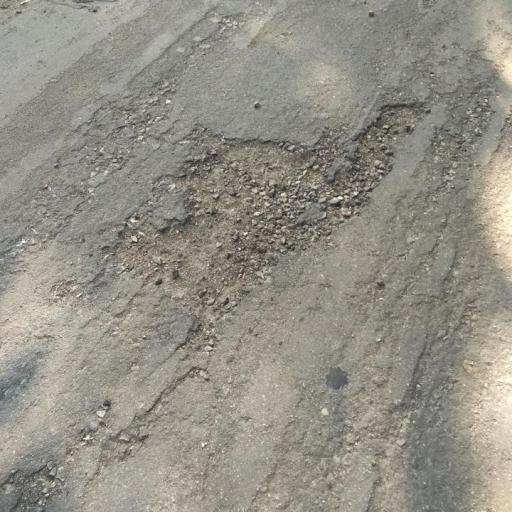

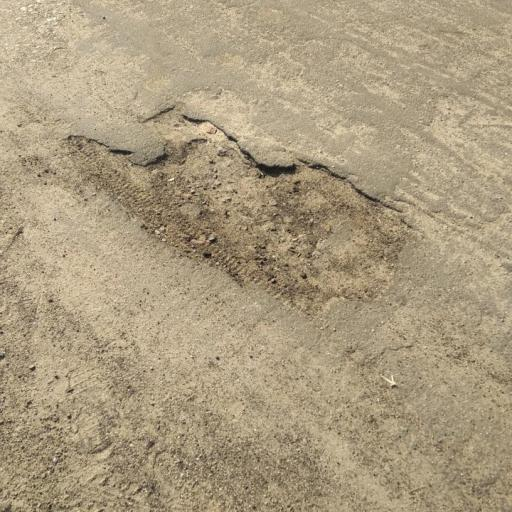

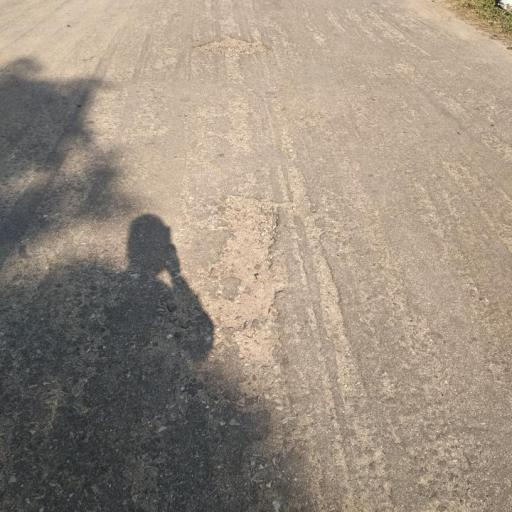

In [15]:
sample_images = list(os.listdir(path))[:3]
for image in sample_images:
  # Removed the extra '.jpg' as it's already part of the image filename
  image_display = Image(filename=f"{path}/{image}", height=200)
  display(image_display)
  print('\n')

# Model traning


In [16]:
print(HOME)

/content/drive/MyDrive/train_yolov8


In [17]:
%cd {HOME}
model = YOLO("yolov8s-seg.pt")

model.train(
    data = "/content/drive/MyDrive/train_yolov8/datasets/pothole-detection-4/data.yaml",
    epochs = 50,
    imgsz = 640,
    batch = 50,
    name = "yolov8_pothole_seg_custom",
    project = "runs/train",
    exist_ok = True,
    pretrained = True,
    device = device
)

/content/drive/MyDrive/train_yolov8
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=50, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/train_yolov8/datasets/pothole-detection-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_pothole_seg_custom, nbs=64

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b3b4d21d2b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

# model validation

In [20]:
model = YOLO("/content/drive/MyDrive/train_yolov8/runs/segment/runs/train/yolov8_pothole_seg_custom/weights/best.pt")
metrics = model.val()
print(metrics)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8s-seg summary (fused): 86 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 1.9±1.1 ms, read: 2.4±3.4 MB/s, size: 58.0 KB)
val: Scanning /content/drive/MyDrive/train_yolov8/datasets/pothole-detection-4/valid/labels.cache... 104 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 104/104 13.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 18.5s/it 2:09
                   all        104        201       0.73      0.687      0.749       0.44      0.761      0.687      0.749      0.439
Speed: 8.8ms preprocess, 1194.7ms inference, 0.0ms loss, 6.8ms postprocess per image
Results saved to /content/drive/MyDrive/train_yolov8/datasets/runs/segment/val
ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultr

# Testing

In [32]:
path = "/content/drive/MyDrive/train_yolov8/datasets/pothole-detection-4/test/images"
test_images = list(os.listdir(path))[:5]

In [33]:
test_images

['img-106_jpg.rf.9986a19ff864efaae8a530d4583df405.jpg',
 'img-113_jpg.rf.90f6abb535b585fa582cf576dae2540b.jpg',
 'img-117_jpg.rf.237e44b6072f58bae948674d81230291.jpg',
 'img-122_jpg.rf.526cc7ce4aa4e039901c1c4fa2de8953.jpg',
 'img-127_jpg.rf.edb0e376db522fefb16003299c38df2a.jpg']


image 1/1 /content/drive/MyDrive/train_yolov8/datasets/pothole-detection-4/test/images/img-127_jpg.rf.edb0e376db522fefb16003299c38df2a.jpg: 640x640 3 potholes, 1929.2ms
Speed: 8.6ms preprocess, 1929.2ms inference, 19.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/train_yolov8/datasets/runs/segment/predict
2 labels saved to /content/drive/MyDrive/train_yolov8/datasets/runs/segment/predict/labels


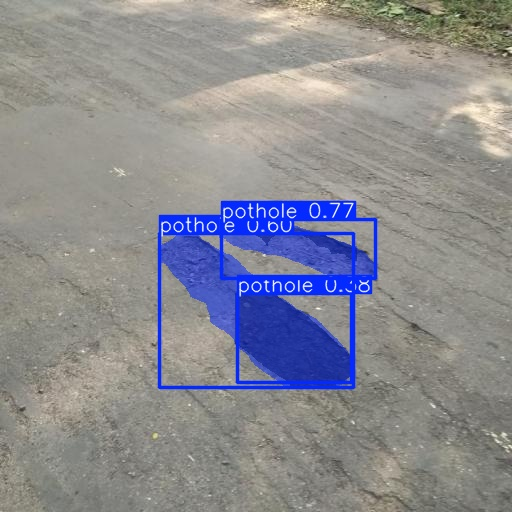

In [45]:
# testing
import os

results = model.predict(
    source = f"{path}/{test_images[4]}",
    conf=0.25,
    save=True,
    save_txt=True,
    save_conf=True
)

# Construct the path to the saved image
saved_image_dir = results[0].save_dir
saved_image_filename = os.path.basename(results[0].path)
saved_image_path = os.path.join(saved_image_dir, saved_image_filename)

Image(filename=saved_image_path, height=600)

In [44]:
saved_image_dir

'/content/drive/MyDrive/train_yolov8/datasets/runs/segment/predict'

In [23]:
saved_image_filename

'img-106_jpg.rf.9986a19ff864efaae8a530d4583df405.jpg'

In [24]:
saved_image_path

'/content/drive/MyDrive/train_yolov8/datasets/runs/segment/predict/img-106_jpg.rf.9986a19ff864efaae8a530d4583df405.jpg'

In [27]:
# exporting the model
%cd {HOME}
# model = YOLO("path/to/your/best.pt")
model.export(format="onnx")

/content/drive/MyDrive/train_yolov8
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/train_yolov8/runs/segment/runs/train/yolov8_pothole_seg_custom/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 37, 8400), (1, 32, 160, 160)) (22.8 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 568ms
Prepared 4 packages in 4.49s
Installed 4 packages in 676ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime==1.24.2
 + onnxslim==0.1.86

requirements: AutoUpdate success ✅ 6.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.2

Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 


ONNX: slimming with onnxslim 0.1.86...
ONNX: export success ✅ 11.6s, saved as '/content/drive/MyDrive/train_yolov8/runs/segment/runs/train/yolov8_pothole_seg_custom/weights/best.onnx' (45.2 MB)

Export complete (14.1s)
Results saved to /content/drive/MyDrive/train_yolov8/runs/segment/runs/train/yolov8_pothole_seg_custom/weights
Predict:         yolo predict task=segment model=/content/drive/MyDrive/train_yolov8/runs/segment/runs/train/yolov8_pothole_seg_custom/weights/best.onnx imgsz=640 
Validate:        yolo val task=segment model=/content/drive/MyDrive/train_yolov8/runs/segment/runs/train/yolov8_pothole_seg_custom/weights/best.onnx imgsz=640 data=/content/drive/MyDrive/train_yolov8/datasets/pothole-detection-4/data.yaml  
Visualize:       https://netron.app


'/content/drive/MyDrive/train_yolov8/runs/segment/runs/train/yolov8_pothole_seg_custom/weights/best.onnx'

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [53]:
result_df = pd.read_csv(r"/content/drive/MyDrive/train_yolov8/runs/segment/runs/train/yolov8_pothole_seg_custom/results.csv")
result_df.head()

,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2
0,1,700.981,1.56464,3.18785,2.51896,1.58023,0,0.06773,0.36318,0.04173,...,0.03777,0.01254,2.40824,5.41066,30.74480,2.76626,0,0.000655,0.000655,0.000655
1,2,780.431,1.61720,2.86561,1.79371,1.62692,0,0.00681,0.28856,0.00443,...,0.00292,0.00070,3.46668,NaN,inf,28.13620,0,0.001295,0.001295,0.001295
2,3,860.885,1.70830,2.93715,1.89752,1.68832,0,0.03951,0.11940,0.01622,...,0.00541,0.00161,2.62975,8.35618,7.96687,3.70505,0,0.001909,0.001909,0.001909
3,4,945.343,1.67977,2.91555,1.87628,1.68511,0,0.23969,0.18905,0.10941,...,0.09119,0.03312,1.81158,4.76290,6.09870,2.03093,0,0.001881,0.001881,0.001881
4,5,1026.270,1.60994,2.83246,1.76981,1.62656,0,0.46678,0.43117,0.39947,...,0.40849,0.18947,1.52272,3.20933,2.69228,1.66602,0,0.001842,0.001842,0.001842


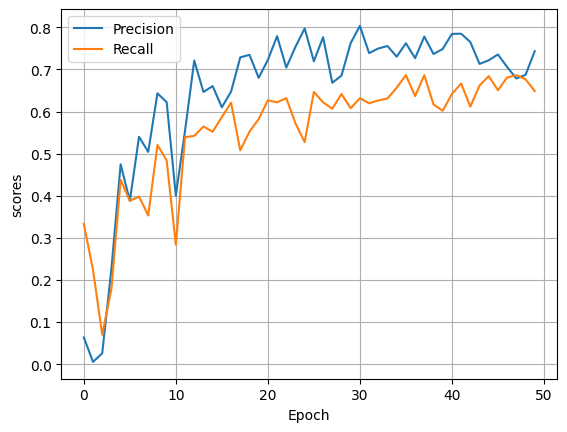

In [60]:
sns.lineplot(result_df['metrics/precision(M)'], label='Precision')
sns.lineplot(result_df['metrics/recall(M)'], label='Recall')
plt.xlabel('Epoch')
plt.ylabel('scores')
plt.legend()
plt.grid()
plt.show()